In [14]:
import pandas as pd
import matplotlib.pyplot as plt

Clearly describe the data source and method of collection

Justify why the dataset is relevant to the research questions

Provide before-and-after snapshots of the dataset (raw vs processed)

In [2]:
raw = pd.read_csv('Data/gas_data.csv')

## Data Collection 

The gas analysis is supported by data from the AAA Fuel prices database. This is a reputable, open source, online dashboard that contains information pretaining to all 50 United States. This can be drilled up to show nationwide averages, or drilled down to metro level by state. 

On the nationwide level, statewide, and metro-level, the observations are formated in a simple table with rows being the "current avg", "yesterday avg", "week ago avg", "month ago avg", and "year ago avg" for each column, which represents types of gas. 

AAA provides real time, daily updates to the dashboard. To access data from pervious years on that observational leve, we utilized the Wayback Machine from Internet Archive. 

We scraped historic data from the Wayback machine using ths Florida AAA gas prices website. This resulted in a .csv file with each row being that observation for a certain day in a certain metro.  

There were no applicable APIs that would allow us to get this rich dataset. The AAA data set through the Wayback Machine was the optimal choice for the data collection as no other online source would have provided means to access metro level data at the required observational level. 

In [ ]:
# Pre-processed, raw data
raw.head(10)

,date,metro,regular,mid,premium,reg_delt
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,NaN
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,0.000000
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,19.516562
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000
5,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000
6,2022-03-22,Bradenton-Sarasota-Venice,4.119,4.547,4.827,2.846442
7,2022-03-22,Bradenton-Sarasota-Venice,4.119,4.547,4.827,0.000000
8,2022-04-01,Bradenton-Sarasota-Venice,4.195,4.601,4.870,1.845108
9,2022-04-01,Bradenton-Sarasota-Venice,4.195,4.601,4.870,0.000000


## Data cleaning and preprocessing

In [11]:
raw.shape

(11544, 6)

**Handling Issues / Noise in the data**

The diesel column was missing 24 values. Our analysis was focused on consumer gas rather than commercial diesel consumption, so we preformed feature selected and disregarded that variable. 

**Understanding the Data**

In [12]:
print(raw.dtypes)

date         object
metro        object
regular     float64
mid         float64
premium     float64
reg_delt    float64
dtype: object


| column name | raw | processed |
| --- | --- | --- |
| date | object | date object |
| metro | object | categorical |
| regular | float64 | numerical|
| mid | float64 | numerical |
| premium | float64 | numerical |


**Basic statistical analysis**


outlier detection 

{'whiskers': [<matplotlib.lines.Line2D at 0x14d9ff4d0>,
 'caps': [<matplotlib.lines.Line2D at 0x14d9ff750>,
 'boxes': [<matplotlib.lines.Line2D at 0x14d9ff390>],
 'medians': [<matplotlib.lines.Line2D at 0x14d9ff9d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x14d9ffb10>],
 'means': []}

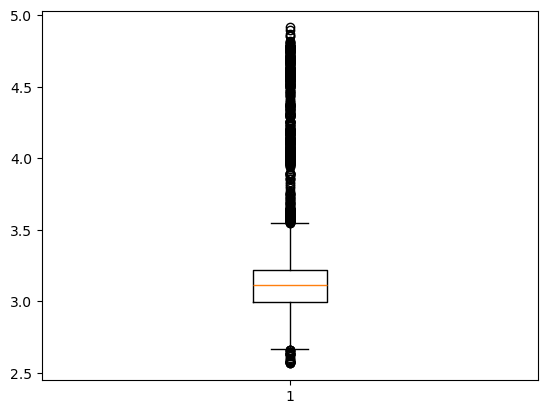

In [19]:
plt.boxplot(raw['regular'])

In [21]:
df = pd.read_csv('Data/gas_coordinates.csv')
df.head(10)

,date,metro,regular,mid,premium,reg_delt,met,lat,lng
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,19.516562,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
5,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
6,2022-03-22,Bradenton-Sarasota-Venice,4.119,4.547,4.827,2.846442,North Port-Bradenton-Sarasota,27.3479,-82.3223
7,2022-03-22,Bradenton-Sarasota-Venice,4.119,4.547,4.827,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
8,2022-04-01,Bradenton-Sarasota-Venice,4.195,4.601,4.870,1.845108,North Port-Bradenton-Sarasota,27.3479,-82.3223
9,2022-04-01,Bradenton-Sarasota-Venice,4.195,4.601,4.870,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [27]:
df['reg_delt'].describe()

count    11520.000000
mean        -0.013665
std          2.173188
min        -16.880398
25%         -0.825921
50%         -0.379976
75%          0.189304
max         26.802508
Name: reg_delt, dtype: float64